In [28]:
import pandas as pd

In [29]:
df=pd.read_csv('../datasets/raw/POWER_Point_Daily_19810101_20210303_008d10N_081d33E_LST.csv')
df1=pd.read_csv('../datasets/raw/sri_lanka_north_central_polonnaruwa_1_month_rainfall_aggregate (1).csv')

In [30]:
df

,YEAR,DOY,T2M,T2MDEW,TS,T2M_RANGE,T2M_MAX,T2M_MIN,QV2M,RH2M,PS,WS2M,WS2M_MAX,WS2M_MIN,GWETTOP,GWETROOT,GWETPROF
0,1981,1,24.82,22.62,25.03,4.21,27.32,23.11,17.15,87.77,100.51,2.80,3.81,1.80,0.71,0.64,0.64
1,1981,2,24.74,22.34,25.05,4.43,27.51,23.08,16.85,86.83,100.53,2.10,2.75,1.62,0.77,0.67,0.65
2,1981,3,24.64,22.60,24.86,4.62,27.32,22.70,17.13,88.55,100.53,3.31,5.22,1.31,0.73,0.68,0.66
3,1981,4,24.71,21.74,24.78,4.62,27.63,23.01,16.24,83.89,100.62,2.85,4.52,1.86,0.75,0.68,0.67
4,1981,5,24.30,21.29,24.48,4.94,27.32,22.38,15.78,83.66,100.69,2.64,4.22,1.77,0.81,0.72,0.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14667,2021,58,25.72,21.21,25.75,7.63,30.24,22.61,15.76,77.35,100.33,1.21,1.95,0.25,0.78,0.77,0.77
14668,2021,59,24.97,21.49,25.01,7.46,29.03,21.57,16.03,81.68,100.41,2.01,3.04,1.17,0.77,0.76,0.76
14669,2021,60,25.25,21.47,25.23,6.59,29.10,22.51,15.96,80.16,100.69,2.16,3.62,1.38,0.76,0.75,0.75
14670,2021,61,25.13,20.72,25.24,6.38,28.71,22.33,15.24,77.10,100.69,2.40,3.83,1.54,0.75,0.74,0.74


In [31]:
df=df.drop('PS',axis=1)

In [32]:
df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['DOY'].astype(str), format='%Y-%j').dt.strftime('%Y-%m-%d')

In [33]:
df=df.drop(['YEAR','DOY'], axis=1)

In [34]:
df1.head()

,Date,1_month_rainfall_aggregate,1_month_rainfall_aggregate_avg
0,1981-01-01,NaN,NaN
1,1981-01-11,NaN,NaN
2,1981-01-21,89.5776,180.1767
3,1981-02-01,72.4396,143.8716
4,1981-02-11,65.2500,107.4868


In [35]:
df.head()

,T2M,T2MDEW,TS,T2M_RANGE,T2M_MAX,T2M_MIN,QV2M,RH2M,WS2M,WS2M_MAX,WS2M_MIN,GWETTOP,GWETROOT,GWETPROF,Date
0,24.82,22.62,25.03,4.21,27.32,23.11,17.15,87.77,2.80,3.81,1.80,0.71,0.64,0.64,1981-01-01
1,24.74,22.34,25.05,4.43,27.51,23.08,16.85,86.83,2.10,2.75,1.62,0.77,0.67,0.65,1981-01-02
2,24.64,22.60,24.86,4.62,27.32,22.70,17.13,88.55,3.31,5.22,1.31,0.73,0.68,0.66,1981-01-03
3,24.71,21.74,24.78,4.62,27.63,23.01,16.24,83.89,2.85,4.52,1.86,0.75,0.68,0.67,1981-01-04
4,24.30,21.29,24.48,4.94,27.32,22.38,15.78,83.66,2.64,4.22,1.77,0.81,0.72,0.70,1981-01-05


In [36]:
import numpy as np

df['Date'] = pd.to_datetime(df['Date'])

def map_to_closest_special_date(date):
    month_start = date.replace(day=1)
    special_dates = [month_start, month_start + pd.DateOffset(days=10), month_start + pd.DateOffset(days=20)]
    closest_date = min(special_dates, key=lambda x: abs(date - x))
    return closest_date

df['Date'] =df['Date'].apply(map_to_closest_special_date)

mapped_data = df.groupby('Date').agg('mean')



In [37]:
mapped_data.head()

,T2M,T2MDEW,TS,T2M_RANGE,T2M_MAX,T2M_MIN,QV2M,RH2M,WS2M,WS2M_MAX,WS2M_MIN,GWETTOP,GWETROOT,GWETPROF
Date,,,,,,,,,,,,,,
1981-01-01,24.541667,21.896667,24.731667,4.761667,27.426667,22.665000,16.408333,85.530000,2.646667,3.923333,1.598333,0.753333,0.683333,0.670000
1981-01-11,24.110000,20.719000,24.168000,6.160000,27.646000,21.486000,15.263000,81.906000,2.377000,3.563000,1.460000,0.694000,0.660000,0.662000
1981-01-21,24.166667,19.898667,24.516667,6.551333,27.899333,21.348000,14.499333,77.967333,2.828667,4.071333,1.786000,0.587333,0.573333,0.581333
1981-02-01,24.581667,20.551667,24.835000,5.710000,27.866667,22.156667,15.196667,79.531667,2.663333,4.050000,1.698333,0.565000,0.535000,0.536667
1981-02-11,24.756000,20.961000,24.985000,6.982000,28.771000,21.789000,15.552000,80.534000,2.365000,3.541000,1.503000,0.611000,0.580000,0.578000


In [38]:
df1['Date']=pd.to_datetime(df1['Date'])
merged_df = pd.merge(mapped_data, df1, on='Date', how='left')

In [39]:
merged_df.head()

,Date,T2M,T2MDEW,TS,T2M_RANGE,T2M_MAX,T2M_MIN,QV2M,RH2M,WS2M,WS2M_MAX,WS2M_MIN,GWETTOP,GWETROOT,GWETPROF,1_month_rainfall_aggregate,1_month_rainfall_aggregate_avg
0,1981-01-01,24.541667,21.896667,24.731667,4.761667,27.426667,22.665000,16.408333,85.530000,2.646667,3.923333,1.598333,0.753333,0.683333,0.670000,NaN,NaN
1,1981-01-11,24.110000,20.719000,24.168000,6.160000,27.646000,21.486000,15.263000,81.906000,2.377000,3.563000,1.460000,0.694000,0.660000,0.662000,NaN,NaN
2,1981-01-21,24.166667,19.898667,24.516667,6.551333,27.899333,21.348000,14.499333,77.967333,2.828667,4.071333,1.786000,0.587333,0.573333,0.581333,89.5776,180.1767
3,1981-02-01,24.581667,20.551667,24.835000,5.710000,27.866667,22.156667,15.196667,79.531667,2.663333,4.050000,1.698333,0.565000,0.535000,0.536667,72.4396,143.8716
4,1981-02-11,24.756000,20.961000,24.985000,6.982000,28.771000,21.789000,15.552000,80.534000,2.365000,3.541000,1.503000,0.611000,0.580000,0.578000,65.2500,107.4868


In [40]:
merged_df.isnull().sum()

Date                              0
T2M                               0
T2MDEW                            0
TS                                0
T2M_RANGE                         0
T2M_MAX                           0
T2M_MIN                           0
QV2M                              0
RH2M                              0
WS2M                              0
WS2M_MAX                          0
WS2M_MIN                          0
GWETTOP                           0
GWETROOT                          0
GWETPROF                          0
1_month_rainfall_aggregate        2
1_month_rainfall_aggregate_avg    2
dtype: int64

In [41]:
merged_df=merged_df.dropna()

In [42]:
merged_df.isnull().sum()

Date                              0
T2M                               0
T2MDEW                            0
TS                                0
T2M_RANGE                         0
T2M_MAX                           0
T2M_MIN                           0
QV2M                              0
RH2M                              0
WS2M                              0
WS2M_MAX                          0
WS2M_MIN                          0
GWETTOP                           0
GWETROOT                          0
GWETPROF                          0
1_month_rainfall_aggregate        0
1_month_rainfall_aggregate_avg    0
dtype: int64

In [43]:
merged_df.isnull().values.any()

np.False_

In [44]:
merged_df=merged_df.drop(['1_month_rainfall_aggregate_avg','WS2M_MIN','WS2M_MAX','WS2M','T2M_MIN','T2M_MAX','QV2M'],axis=1)

Silhouette Score for k = 2: 0.4791
Silhouette Score for k = 3: 0.3254
Silhouette Score for k = 4: 0.2650
Silhouette Score for k = 5: 0.2830
Silhouette Score for k = 6: 0.2834
Silhouette Score for k = 7: 0.2615
Silhouette Score for k = 8: 0.2546
Silhouette Score for k = 9: 0.2419
Silhouette Score for k = 10: 0.2380
Silhouette Score for k = 11: 0.2306
Silhouette Score for k = 12: 0.2227
Silhouette Score for k = 13: 0.2368
Silhouette Score for k = 14: 0.2267
Silhouette Score for k = 15: 0.2250
Silhouette Score for k = 16: 0.2155
Silhouette Score for k = 17: 0.2139
Silhouette Score for k = 18: 0.2115
Silhouette Score for k = 19: 0.2020
Silhouette Score for k = 20: 0.2038


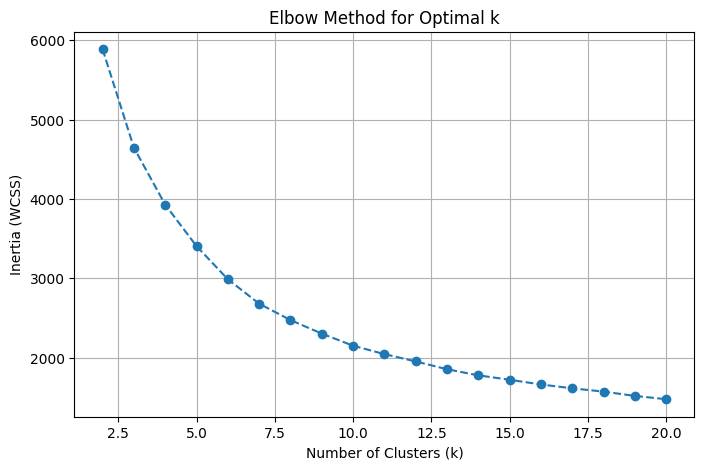

Optimal k based on silhouette score: 2
                     T2M     T2MDEW         TS  T2M_RANGE       RH2M  \
Cluster_Label                                                          
0              28.309575  22.192995  29.235332   8.148792  71.592937   
1              25.849798  22.957420  26.082899   5.139785  84.679219   

                GWETTOP  GWETROOT  GWETPROF  1_month_rainfall_aggregate  
Cluster_Label                                                            
0              0.428680  0.456309  0.458060                   80.985763  
1              0.726066  0.697973  0.693612                  246.507353  


In [45]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

X = merged_df.select_dtypes(include=['float64', 'int64'])

X = X.apply(pd.to_numeric, errors='coerce')


imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

inertia = []
silhouette_scores = []  

for i in range(2, 21):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    inertia.append(kmeans.inertia_)
    
   
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)
    
    print(f"Silhouette Score for k = {i}: {score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(2, 21), inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.grid()
plt.show()


best_k = range(2, 21)[silhouette_scores.index(max(silhouette_scores))]
print(f"Optimal k based on silhouette score: {best_k}")

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
merged_df['Cluster_Label'] = kmeans.fit_predict(X_scaled)


print(merged_df.groupby('Cluster_Label').mean(numeric_only=True))


In [46]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(X_scaled, merged_df['Cluster_Label'])
print(f'Silhouette Score for k=2: {silhouette_avg:.2f}')

Silhouette Score for k=2: 0.48


In [47]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt


X = merged_df.select_dtypes(include=['float64', 'int64'])


X = X.apply(pd.to_numeric, errors='coerce')

imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)


aic_scores = []
bic_scores = []
silhouette_scores = []


for i in range(2, 21):
    gmm = GaussianMixture(n_components=i, random_state=42)
    gmm_labels = gmm.fit_predict(X_scaled)
    
    aic_scores.append(gmm.aic(X_scaled))
    bic_scores.append(gmm.bic(X_scaled))
    
    
    score = silhouette_score(X_scaled, gmm_labels)
    silhouette_scores.append(score)
    
    print(f"Silhouette Score for k = {i}: {score:.4f}")




best_k = range(2, 21)[silhouette_scores.index(max(silhouette_scores))]
print(f"Optimal number of components based on silhouette score: {best_k}")

gmm = GaussianMixture(n_components=best_k, random_state=42)
merged_df['GMM_Cluster_Label'] = gmm.fit_predict(X_scaled)

print(merged_df.groupby('GMM_Cluster_Label').mean(numeric_only=True))


Silhouette Score for k = 2: 0.4729
Silhouette Score for k = 3: 0.2831
Silhouette Score for k = 4: 0.2514
Silhouette Score for k = 5: 0.2172
Silhouette Score for k = 6: 0.1773
Silhouette Score for k = 7: 0.1716
Silhouette Score for k = 8: 0.1080
Silhouette Score for k = 9: 0.1136
Silhouette Score for k = 10: 0.0929
Silhouette Score for k = 11: 0.0897
Silhouette Score for k = 12: 0.0738
Silhouette Score for k = 13: 0.0857
Silhouette Score for k = 14: 0.0747
Silhouette Score for k = 15: 0.0717
Silhouette Score for k = 16: 0.0626
Silhouette Score for k = 17: 0.0789
Silhouette Score for k = 18: 0.0739
Silhouette Score for k = 19: 0.0483
Silhouette Score for k = 20: 0.0540
Optimal number of components based on silhouette score: 2
                         T2M     T2MDEW         TS  T2M_RANGE       RH2M  \
GMM_Cluster_Label                                                          
0                  28.294997  22.158561  29.222013   8.170246  71.511072   
1                  25.908236  23.00119

In [48]:
print(merged_df['Cluster_Label'].value_counts())

Cluster_Label
0    895
1    550
Name: count, dtype: int64


In [49]:
merged_df.to_csv('LabeledData.csv')

In [50]:
df=merged_df

Skipping boxplot for column 'Date' as it is not numeric.


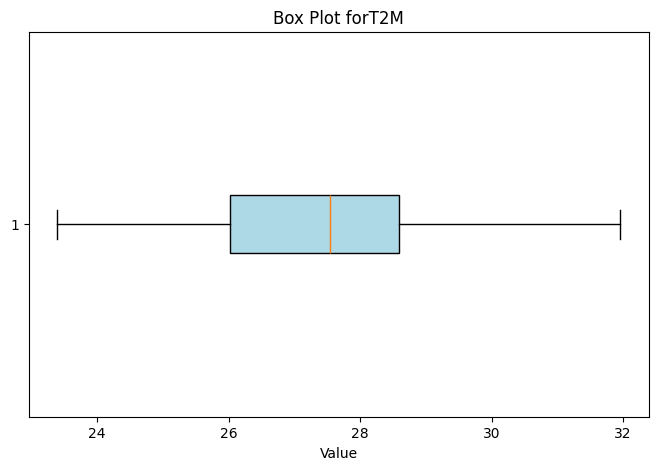

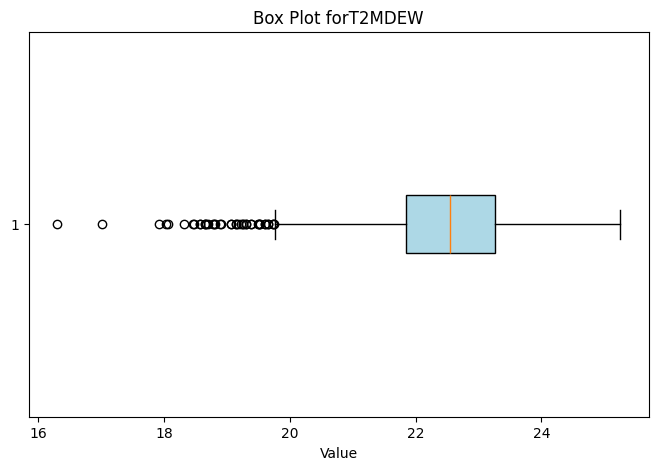

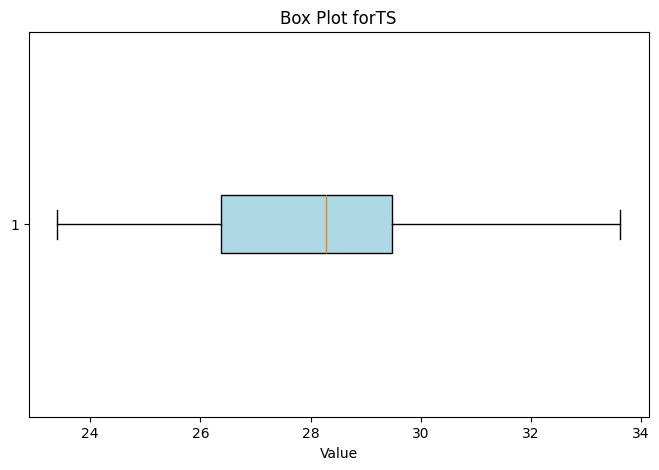

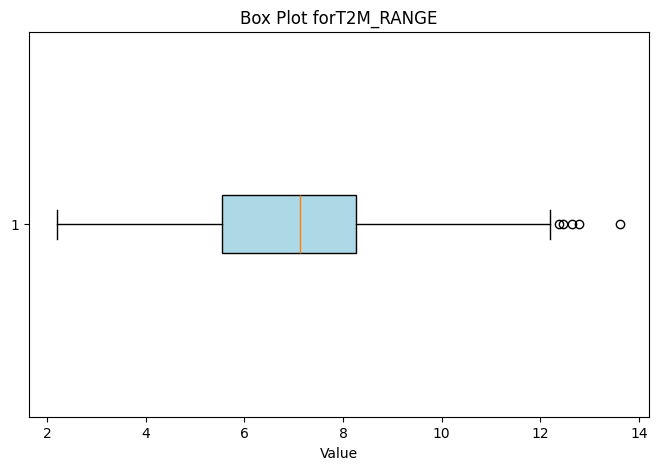

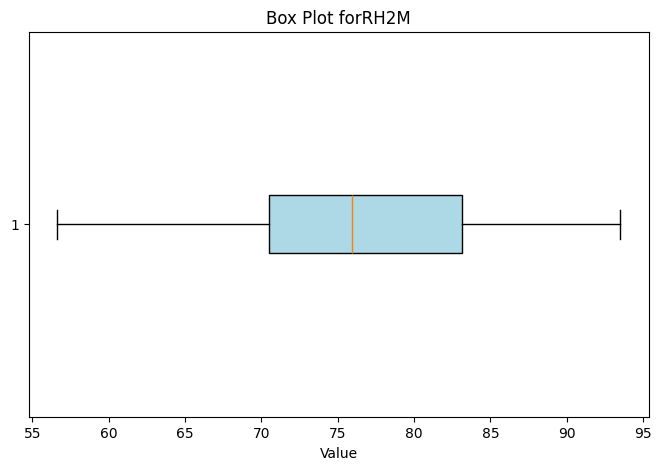

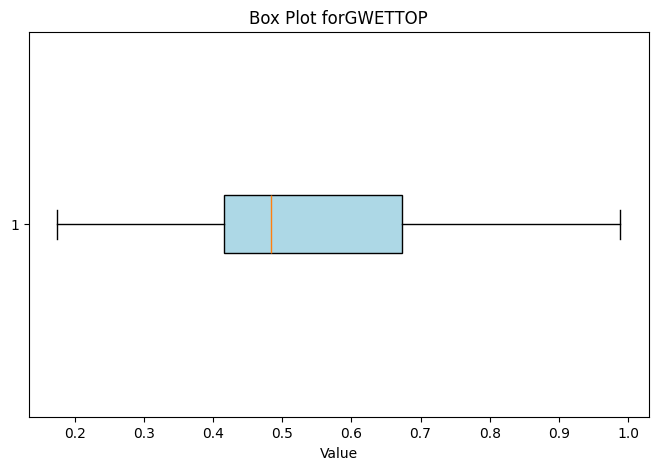

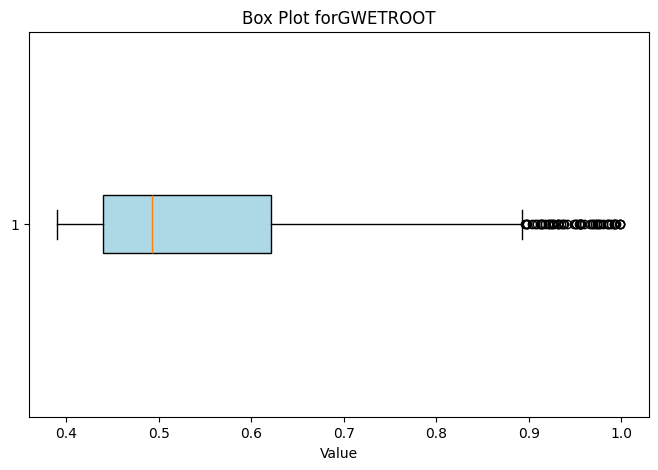

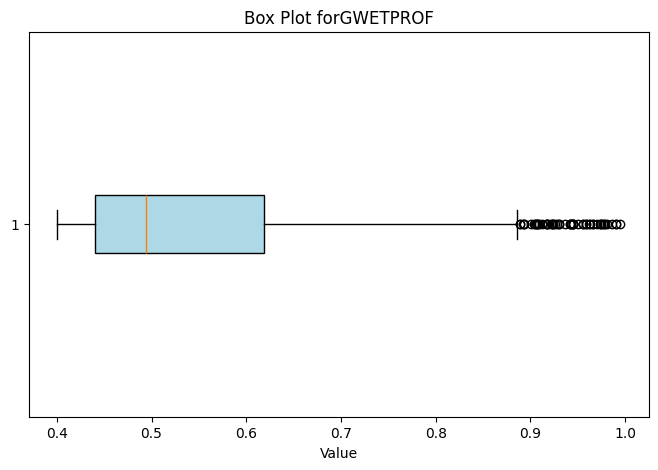

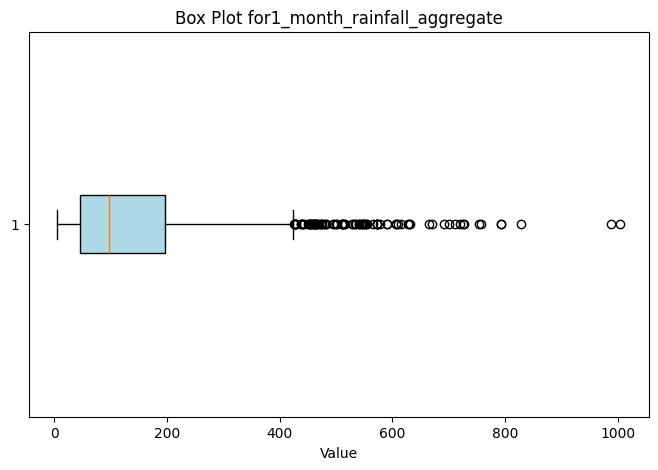

Skipping boxplot for column 'Cluster_Label' as it is not numeric.


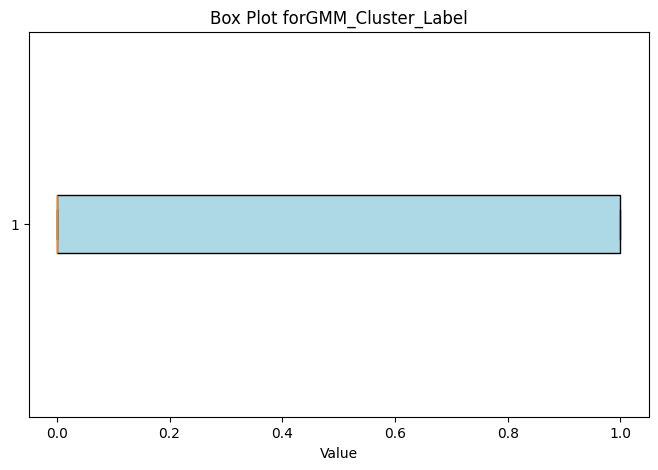

In [51]:
for col in df.columns:
    if df[col].dtype in [int, float]:
        plt.figure(figsize=(8, 5))
        plt.boxplot(df[col], vert=False, patch_artist=True, boxprops=dict(facecolor="lightblue"))
        plt.title("Box Plot for"+col)
        plt.xlabel("Value")
        plt.show()
    else:
        print(f"Skipping boxplot for column '{col}' as it is not numeric.")

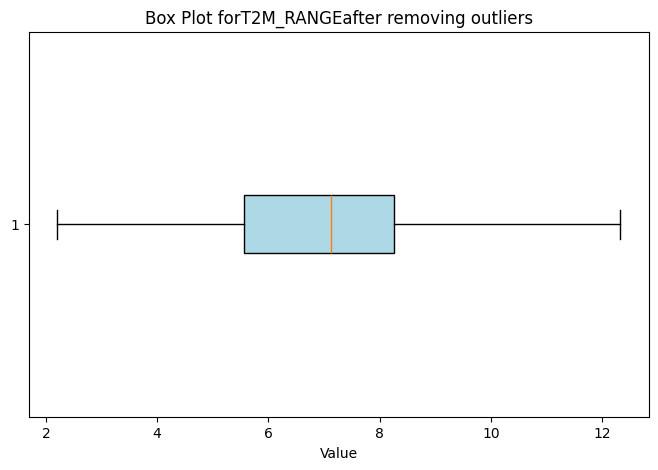

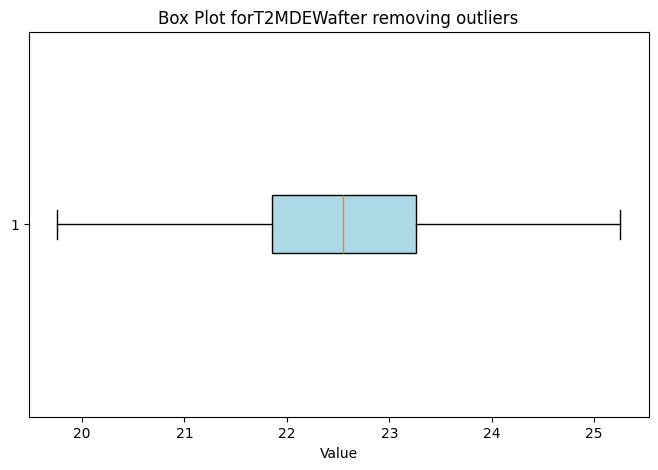

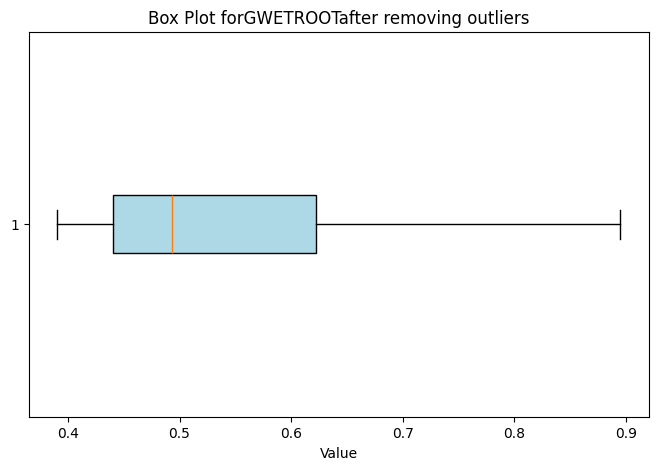

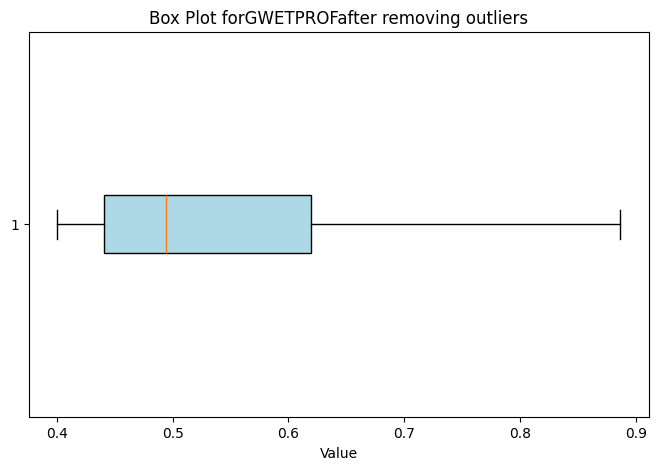

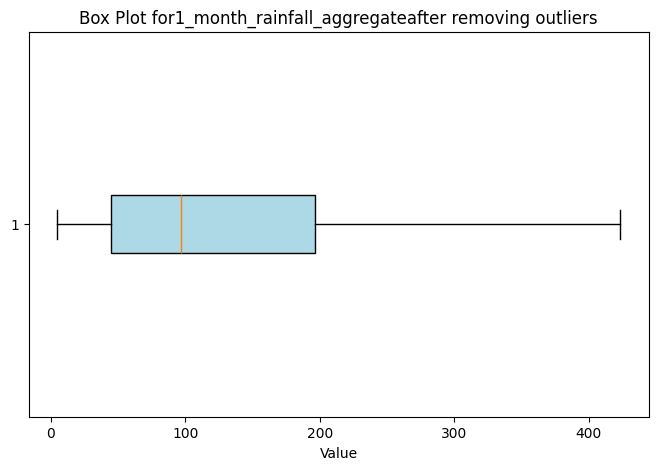

In [52]:
def capping(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR


    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
features_toCap=['T2M_RANGE','T2MDEW','GWETROOT','GWETPROF','1_month_rainfall_aggregate']
for cols in features_toCap:
    capping(cols)
    plt.figure(figsize=(8, 5))
    plt.boxplot(df[cols], vert=False, patch_artist=True, boxprops=dict(facecolor="lightblue"))
    plt.title("Box Plot for"+cols+"after removing outliers")
    plt.xlabel("Value")
    plt.show()


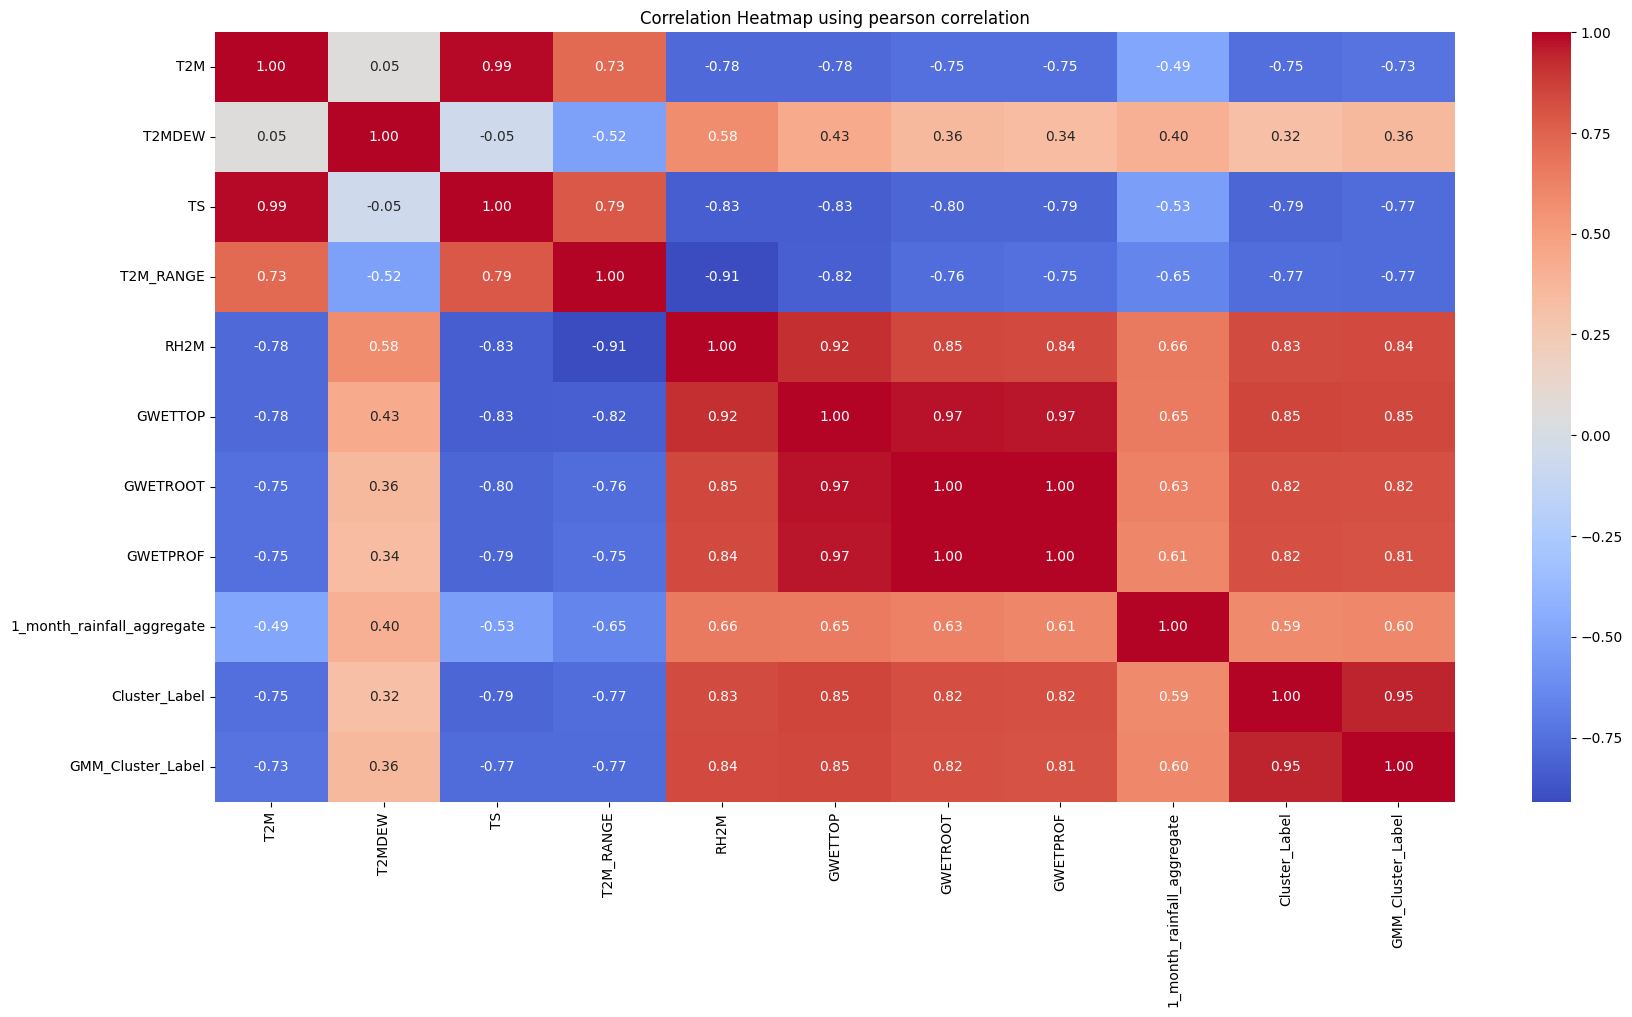

TS and T2M: 0.9885066340550591
T2M and TS: 0.9885066340550591
GWETTOP and RH2M: 0.9170941274241907
RH2M and GWETTOP: 0.9170941274241907
GWETROOT and GWETTOP: 0.9745817826542029
GWETPROF and GWETTOP: 0.9692380734362526
GWETTOP and GWETROOT: 0.9745817826542029
GWETPROF and GWETROOT: 0.9989013791352439
GWETTOP and GWETPROF: 0.9692380734362526
GWETROOT and GWETPROF: 0.9989013791352439
GMM_Cluster_Label and Cluster_Label: 0.9473736599568597
Cluster_Label and GMM_Cluster_Label: 0.9473736599568597
{'Cluster_Label', 'TS', 'RH2M', 'GWETROOT', 'GMM_Cluster_Label', 'GWETTOP', 'T2M', 'GWETPROF'}
['Cluster_Label', 'TS', 'RH2M', 'GWETROOT', 'GMM_Cluster_Label', 'GWETTOP', 'T2M', 'GWETPROF']


In [53]:
import seaborn as sns
correlation_matrix = df.drop(columns="Date").corr(method="pearson")

plt.figure(figsize=(20, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)

plt.title("Correlation Heatmap using pearson correlation")
plt.show()

higly_correlated_features=set()
names_of_features=[]

for col in correlation_matrix.columns:
    for index in correlation_matrix.index:
        if correlation_matrix.loc[index, col] > 0.9 and index != col:
            print(f"{index} and {col}: {correlation_matrix.loc[index, col]}")
            higly_correlated_features.add(index)
print(higly_correlated_features)
for features in higly_correlated_features:
    names_of_features.append(features)

print(names_of_features)



In [54]:
df=df.drop(['TS','GWETPROF','GWETROOT'],axis=1)

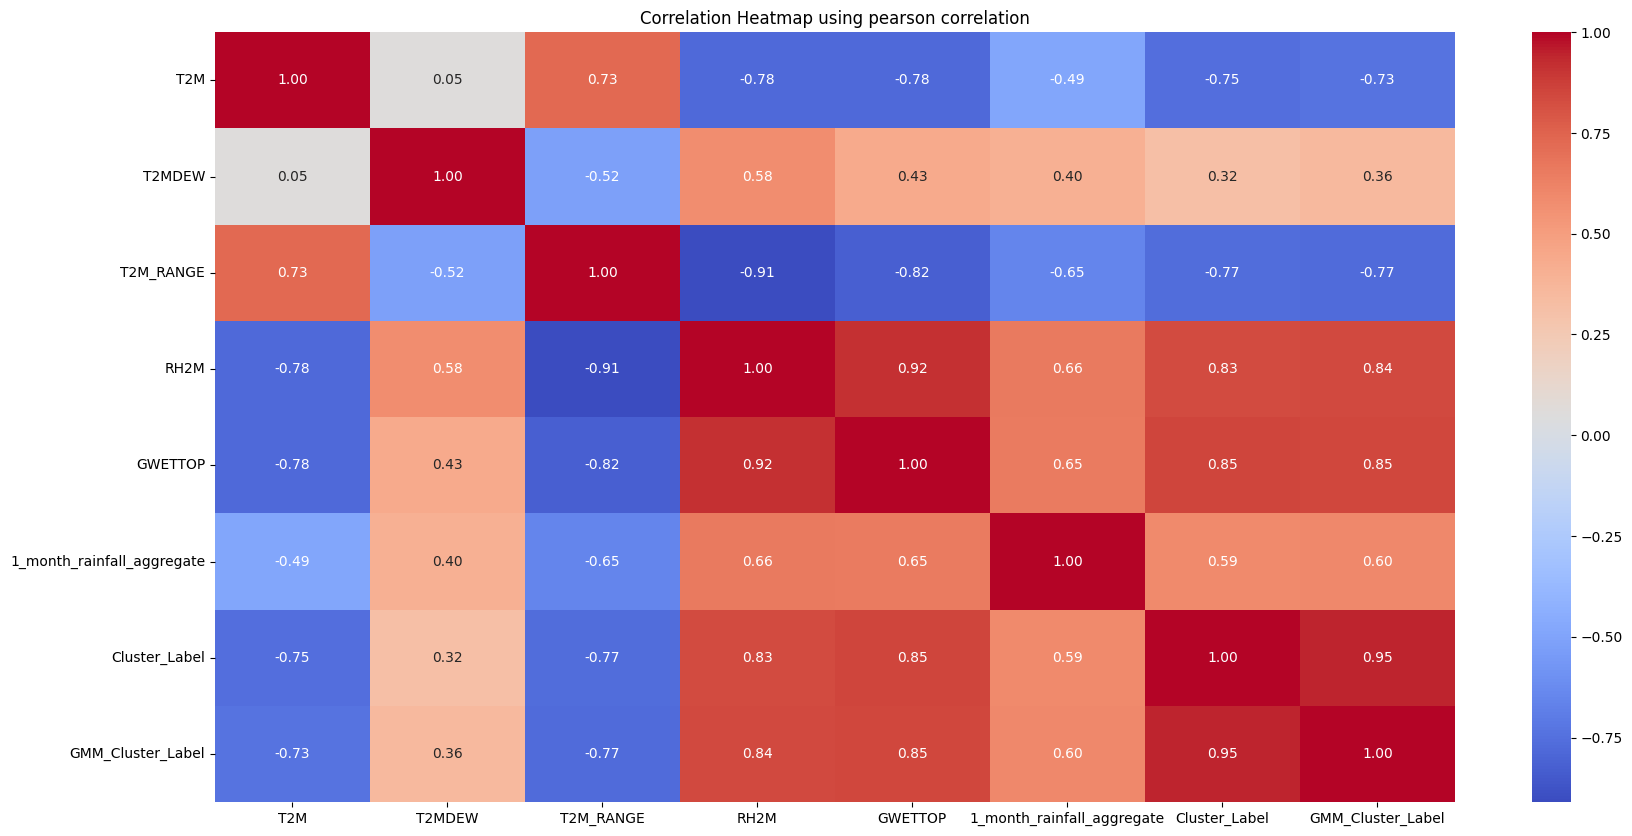

In [55]:
correlation_matrix = df.drop(columns="Date").corr(method="pearson")

plt.figure(figsize=(20, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)

plt.title("Correlation Heatmap using pearson correlation")
plt.show()

In [56]:
df['Date'] = pd.to_datetime(df['Date'])


df['Month'] = df['Date'].dt.month 
df.drop(columns=['Date'], inplace=True)



In [57]:
yala=[4,5,6,7]
df_maha = df[~df['Month'].isin(yala)]

In [58]:
df_maha.info()

<class 'pandas.core.frame.DataFrame'>
Index: 965 entries, 2 to 1446
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   T2M                         965 non-null    float64
 1   T2MDEW                      965 non-null    float64
 2   T2M_RANGE                   965 non-null    float64
 3   RH2M                        965 non-null    float64
 4   GWETTOP                     965 non-null    float64
 5   1_month_rainfall_aggregate  965 non-null    float64
 6   Cluster_Label               965 non-null    int32  
 7   GMM_Cluster_Label           965 non-null    int64  
 8   Month                       965 non-null    int32  
dtypes: float64(6), int32(2), int64(1)
memory usage: 67.9 KB


In [59]:
print(df_maha['Cluster_Label'].value_counts())

Cluster_Label
0    486
1    479
Name: count, dtype: int64


                      Feature  Importance
3                        RH2M    0.301119
4                     GWETTOP    0.284170
0                         T2M    0.164644
2                   T2M_RANGE    0.143469
5  1_month_rainfall_aggregate    0.058025
1                      T2MDEW    0.036280
6                       Month    0.012295


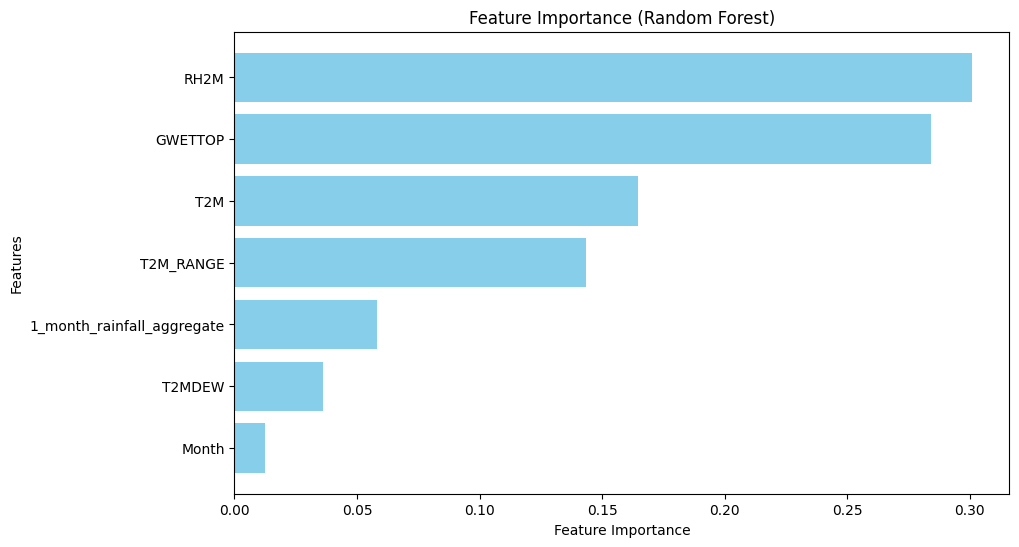

In [60]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

x_train=df_maha.drop(columns=['Cluster_Label','GMM_Cluster_Label'])
y_train=df_maha['Cluster_Label']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)


feature_importances = rf.feature_importances_

features = x_train.columns  
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})



importance_df = importance_df.sort_values(by='Importance', ascending=False)


print(importance_df)


plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.show()


In [61]:
from sklearn.preprocessing import StandardScaler

X=df_maha[['1_month_rainfall_aggregate','T2MDEW','Month']]

scaler=StandardScaler()
X_scale=scaler.fit_transform(X)
Scaled_df=pd.DataFrame(X_scale,columns=X.columns)
Scaled_df.head()


,1_month_rainfall_aggregate,T2MDEW,Month
0,-0.586407,-2.192488,-1.468699
1,-0.720416,-1.592549,-1.222854
2,-0.776635,-1.216477,-1.222854
3,-0.781421,-2.100920,-1.222854
4,-1.223488,-0.413497,-0.977010


In [62]:
import pickle

pickle.dump(scaler,open('StandardScaler.pkl','wb'))

In [63]:
from sklearn.decomposition import PCA
pca=PCA(0.95)
X_pca=pca.fit_transform(Scaled_df)

explained_variance=pca.explained_variance_ratio_
explained_variance

array([0.63452622, 0.2205107 , 0.14496308])

In [64]:
import numpy as np
pca_columns = X_pca[:, :3]
scaled_pca=scaler.fit_transform(pca_columns)
pca_data = np.concatenate([scaled_pca], axis=1)
pca_df = pd.DataFrame(pca_data, columns=['PCACOMP1','PCACOMP2','PCACOMP3'])
pca_df.head()






,PCACOMP1,PCACOMP2,PCACOMP3
0,-1.780082,-0.433574,-1.627375
1,-1.479069,-0.312703,-0.859869
2,-1.336950,-0.412495,-0.381413
3,-1.730179,-0.101366,-1.368670
4,-1.080854,-0.187889,0.928905


In [65]:
pickle.dump(pca,open('pca.pkl','wb'))

In [66]:
df_maha = df_maha.reset_index(drop=True)
pca_df = pca_df.reset_index(drop=True)

In [67]:
df1 = pd.concat([df_maha, pca_df], axis=1)
df1.head()

,T2M,T2MDEW,T2M_RANGE,RH2M,GWETTOP,1_month_rainfall_aggregate,Cluster_Label,GMM_Cluster_Label,Month,PCACOMP1,PCACOMP2,PCACOMP3
0,24.166667,19.898667,6.551333,77.967333,0.587333,89.5776,1,1,1,-1.780082,-0.433574,-1.627375
1,24.581667,20.551667,5.710000,79.531667,0.565000,72.4396,1,1,2,-1.479069,-0.312703,-0.859869
2,24.756000,20.961000,6.982000,80.534000,0.611000,65.2500,1,1,2,-1.336950,-0.412495,-0.381413
3,25.878333,19.998333,8.392500,71.654167,0.480000,64.6379,0,0,2,-1.730179,-0.101366,-1.368670
4,27.590000,21.835000,7.645000,72.365000,0.433333,8.1034,0,0,3,-1.080854,-0.187889,0.928905


In [68]:
df2=df1.drop(['1_month_rainfall_aggregate','T2MDEW','Month','GMM_Cluster_Label'],axis=1)

In [69]:
df2.isnull().sum()

T2M              0
T2M_RANGE        0
RH2M             0
GWETTOP          0
Cluster_Label    0
PCACOMP1         0
PCACOMP2         0
PCACOMP3         0
dtype: int64

In [70]:
df2.to_csv('DSGP1.csv', index=False)